In [5]:
# ============================================================
# AI Innovators Lab: Fake News Detector
# Goal: Train an AI model that predicts whether a news headline
#       is Fake or Real.
#
# Input:
# - News headline
#
# Output:
# - Fake
# - Real
#
# Dataset:
# Fake and Real News Dataset by Clément Bisaillon on Kaggle
# Link: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
#
# Camp version:
# We use only the news title/headline to keep the project simple.
# Students can type a headline and see how the AI classifies it.
#
# Responsible AI Note:
# This model is for education only. It should not be used as a
# real fact-checking tool.
# ============================================================

print("Welcome to the Fake News Detector Project!")
print("Goal: Build an AI model that classifies news headlines as Fake or Real.")
print("Important: This is for education only, not a real fact-checking system.")


Welcome to the Fake News Detector Project!
Goal: Build an AI model that classifies news headlines as Fake or Real.
Important: This is for education only, not a real fact-checking system.


In [6]:
# ============================================================
# Step 1: Install and import required libraries
# ============================================================

!pip install -q kaggle

import os
import zipfile
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [7]:
# ============================================================
# Step 2: Upload Kaggle API key
#
# Before running this:
# 1. Go to Kaggle.com
# 2. Click your profile picture
# 3. Go to Account
# 4. Click "Create New API Token"
# 5. A file named kaggle.json will download
# 6. Upload that file here
# ============================================================

uploaded = files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)

if "kaggle.json" in uploaded:
    shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
    os.chmod("/root/.kaggle/kaggle.json", 600)
    print("Kaggle API key uploaded successfully!")
else:
    print("Please upload your kaggle.json file before downloading the dataset.")

Saving FakeNewsDetector.zip to FakeNewsDetector (1).zip
Please upload your kaggle.json file before downloading the dataset.


In [8]:
# ============================================================
# Step 3: Download the dataset from Kaggle
# ============================================================

!kaggle datasets download -d clmentbisaillon/fake-and-real-news-dataset

print("Dataset downloaded!")

Dataset URL: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
License(s): CC-BY-NC-SA-4.0
fake-and-real-news-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset downloaded!


In [9]:
# ============================================================
# Step 4: Unzip the dataset
# ============================================================

zip_file = "fake-and-real-news-dataset.zip"
extract_folder = "fake_real_news_dataset"

if os.path.exists(extract_folder):
    shutil.rmtree(extract_folder)

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [10]:
# ============================================================
# Step 5: Load Fake.csv and True.csv
#
# Fake.csv contains fake news articles.
# True.csv contains real news articles.
# ============================================================

fake_path = os.path.join(extract_folder, "Fake.csv")
true_path = os.path.join(extract_folder, "True.csv")

fake_news = pd.read_csv(fake_path)
real_news = pd.read_csv(true_path)

print("Fake news data:")
print(fake_news.head())

print("\nReal news data:")
print(real_news.head())

print("\nNumber of fake articles:", len(fake_news))
print("Number of real articles:", len(real_news))

Fake news data:
                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  

Real news data:
                                               title  \
0  As U.S. budget fight looms, Republicans flip t..

In [11]:
# ============================================================
# Step 6: Create labels
#
# We create a new column:
# label = 0 means Fake
# label = 1 means Real
# ============================================================

fake_news["label"] = 0
real_news["label"] = 1

# Combine fake and real news into one dataset
data = pd.concat([fake_news, real_news], axis=0)

# Shuffle the dataset
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print("Combined dataset created!")
print(data[["title", "label"]].head())

Combined dataset created!
                                               title  label
0  Ben Stein Calls Out 9th Circuit Court: Committ...      0
1  Trump drops Steve Bannon from National Securit...      1
2  Puerto Rico expects U.S. to lift Jones Act shi...      1
3   OOPS: Trump Just Accidentally Confirmed He Le...      0
4  Donald Trump heads for Scotland to reopen a go...      1


In [12]:
# ============================================================
# Step 7: Use only headlines/titles
#
# This makes the project simple:
# Input = headline
# Output = Fake or Real
# ============================================================

data = data[["title", "label"]].dropna()

# Remove duplicate headlines if any
data = data.drop_duplicates(subset=["title"])

print("Final dataset size:", len(data))
print(data.head())

Final dataset size: 38729
                                               title  label
0  Ben Stein Calls Out 9th Circuit Court: Committ...      0
1  Trump drops Steve Bannon from National Securit...      1
2  Puerto Rico expects U.S. to lift Jones Act shi...      1
3   OOPS: Trump Just Accidentally Confirmed He Le...      0
4  Donald Trump heads for Scotland to reopen a go...      1



Label counts:
Fake: 17903
Real: 20826


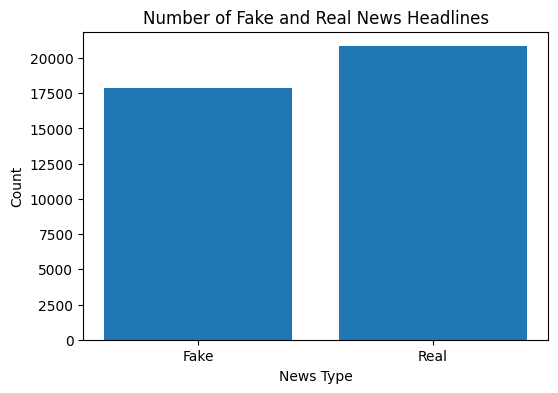

In [13]:
# ============================================================
# Step 8: Explore label counts
# ============================================================

label_counts = data["label"].value_counts().sort_index()

print("\nLabel counts:")
print("Fake:", label_counts.get(0, 0))
print("Real:", label_counts.get(1, 0))

plt.figure(figsize=(6, 4))
plt.bar(["Fake", "Real"], [label_counts.get(0, 0), label_counts.get(1, 0)])
plt.title("Number of Fake and Real News Headlines")
plt.xlabel("News Type")
plt.ylabel("Count")
plt.show()


In [14]:
# ============================================================
# Step 9: Split data into training and testing sets
#
# Training data teaches the AI.
# Testing data checks if the AI learned well.
# ============================================================

X = data["title"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training headlines:", len(X_train))
print("Testing headlines:", len(X_test))

Training headlines: 29046
Testing headlines: 9683


In [15]:
# ============================================================
# Step 10: Convert headlines into numbers
#
# AI models do not understand raw text directly.
# TF-IDF converts words into meaningful numerical features.
# ============================================================

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000
)

X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

print("Headlines converted into numbers!")
print("Number of text features:", len(vectorizer.get_feature_names_out()))

Headlines converted into numbers!
Number of text features: 5000


In [16]:
# ============================================================
# Step 11: Build and train the AI model
#
# Logistic Regression is a strong beginner-friendly model for
# text classification.
# ============================================================

model = LogisticRegression(max_iter=1000)

model.fit(X_train_vectorized, y_train)

print("Model training completed!")

Model training completed!


In [17]:
# ============================================================
# Step 12: Evaluate the model
# ============================================================

y_pred = model.predict(X_test_vectorized)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Fake", "Real"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 93.18 %

Classification Report:
              precision    recall  f1-score   support

        Fake       0.95      0.90      0.92      4476
        Real       0.91      0.96      0.94      5207

    accuracy                           0.93      9683
   macro avg       0.93      0.93      0.93      9683
weighted avg       0.93      0.93      0.93      9683


Confusion Matrix:
[[4010  466]
 [ 194 5013]]


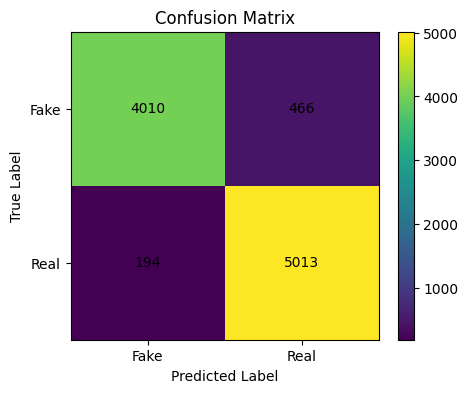

In [18]:
# ============================================================
# Step 13: Visualize confusion matrix
#
# Confusion Matrix:
# Top-left     = Fake predicted as Fake
# Top-right    = Fake predicted as Real
# Bottom-left  = Real predicted as Fake
# Bottom-right = Real predicted as Real
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1], ["Fake", "Real"])
plt.yticks([0, 1], ["Fake", "Real"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [19]:
# ============================================================
# Step 14: Test the model with example headlines
#
# Students can change these examples.
# Reminder: This is an educational model, not a real fact checker.
# ============================================================

example_headlines = [
    "NASA announces new discovery about Mars exploration",
    "Celebrity reveals secret cure that doctors do not want you to know",
    "Government officials announce new education funding plan",
    "Scientists warn fake social media posts spread misinformation quickly",
    "Breaking: Local school wins national robotics competition"
]

example_vectorized = vectorizer.transform(example_headlines)
example_predictions = model.predict(example_vectorized)
example_probabilities = model.predict_proba(example_vectorized)

print("Example Headline Predictions:\n")

for headline, prediction, probability in zip(example_headlines, example_predictions, example_probabilities):
    label = "REAL" if prediction == 1 else "FAKE"
    confidence = max(probability) * 100

    print("Headline:", headline)
    print("Prediction:", label)
    print("Confidence:", round(confidence, 2), "%")
    print("-" * 70)

Example Headline Predictions:

Headline: NASA announces new discovery about Mars exploration
Prediction: FAKE
Confidence: 64.35 %
----------------------------------------------------------------------
Headline: Celebrity reveals secret cure that doctors do not want you to know
Prediction: FAKE
Confidence: 89.29 %
----------------------------------------------------------------------
Headline: Government officials announce new education funding plan
Prediction: REAL
Confidence: 91.27 %
----------------------------------------------------------------------
Headline: Scientists warn fake social media posts spread misinformation quickly
Prediction: REAL
Confidence: 52.43 %
----------------------------------------------------------------------
Headline: Breaking: Local school wins national robotics competition
Prediction: FAKE
Confidence: 92.55 %
----------------------------------------------------------------------


In [20]:
# ============================================================
# Step 15: Let students type their own headline
#
# Use made-up or public example headlines.
# Do not use this as a real news verification tool.
# ============================================================

student_headline = input("Type a news headline to test: ")

student_vectorized = vectorizer.transform([student_headline])
student_prediction = model.predict(student_vectorized)[0]
student_probability = model.predict_proba(student_vectorized)[0]

if student_prediction == 1:
    print("\nThe AI predicts: REAL")
else:
    print("\nThe AI predicts: FAKE")

print("Confidence:", round(max(student_probability) * 100, 2), "%")
print("\nReminder: This model is for education only. It is not a real fact-checking tool.")

Type a news headline to test: United Nations is giving 10 billions dollars

The AI predicts: FAKE
Confidence: 86.2 %

Reminder: This model is for education only. It is not a real fact-checking tool.



Words more associated with REAL headlines:
- says
- factbox
- house
- china
- tax
- seeks
- senate
- talks
- myanmar
- eu
- turkey
- urges
- britain
- pm
- opposition
- south
- rohingya
- zimbabwe
- minister
- court

Words more associated with FAKE headlines:
- video
- watch
- gop
- hillary
- just
- breaking
- racist
- donald
- tweets
- details
- bernie
- america
- isis
- black
- images
- muslim
- gets
- wow
- audio
- image


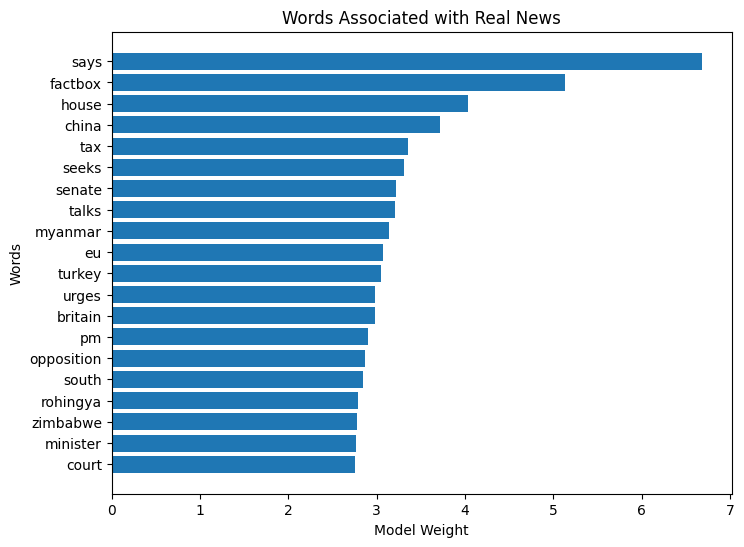

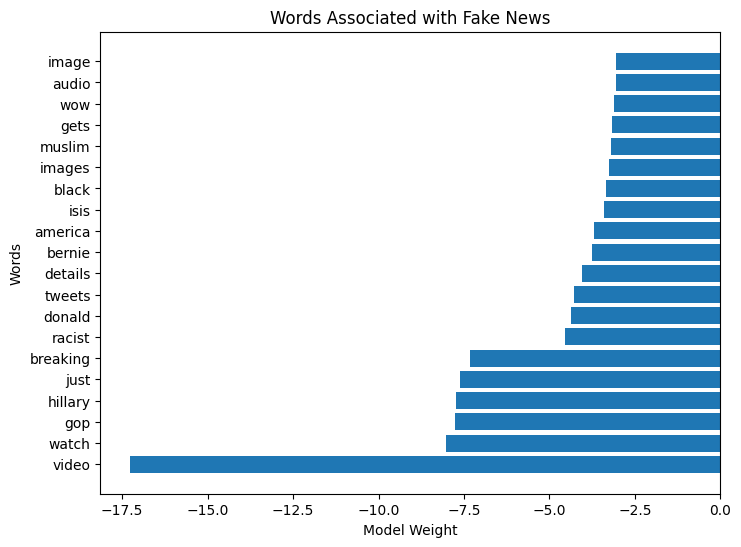

In [21]:
# ============================================================
# Step 16: Show words associated with Fake and Real headlines
#
# This helps students understand what text patterns the model learned.
# ============================================================

feature_names = np.array(vectorizer.get_feature_names_out())

# Logistic Regression coefficients:
# Positive values lean toward Real.
# Negative values lean toward Fake.
coefficients = model.coef_[0]

top_real_indices = np.argsort(coefficients)[-20:]
top_fake_indices = np.argsort(coefficients)[:20]

top_real_words = feature_names[top_real_indices]
top_fake_words = feature_names[top_fake_indices]

print("\nWords more associated with REAL headlines:")
for word in top_real_words[::-1]:
    print("-", word)

print("\nWords more associated with FAKE headlines:")
for word in top_fake_words:
    print("-", word)

plt.figure(figsize=(8, 6))
plt.barh(top_real_words, coefficients[top_real_indices])
plt.title("Words Associated with Real News")
plt.xlabel("Model Weight")
plt.ylabel("Words")
plt.show()

plt.figure(figsize=(8, 6))
plt.barh(top_fake_words, coefficients[top_fake_indices])
plt.title("Words Associated with Fake News")
plt.xlabel("Model Weight")
plt.ylabel("Words")
plt.show()


In [22]:
# ============================================================
# Step 17: Save the model and vectorizer
#
# For text models, we must save:
# - the trained model
# - the vectorizer that converts text into numbers
# ============================================================

with open("fake_news_detector_model.pkl", "wb") as file:
    pickle.dump(model, file)

with open("headline_vectorizer.pkl", "wb") as file:
    pickle.dump(vectorizer, file)

print("Model saved as fake_news_detector_model.pkl")
print("Vectorizer saved as headline_vectorizer.pkl")

# ============================================================
# Step 18: Reflection questions for final showcase
# ============================================================

reflection_questions = [
    "1. What problem does your AI model try to solve?",
    "2. What dataset did you use?",
    "3. What input did the model use?",
    "4. What does the model predict?",
    "5. What was your model accuracy?",
    "6. Did the model make any mistakes?",
    "7. Why is fake news detection difficult?",
    "8. Why should this model not be used as a real fact-checker?",
    "9. How could this AI system be improved?"
]

print("\nReflection Questions:")
for question in reflection_questions:
    print(question)


Model saved as fake_news_detector_model.pkl
Vectorizer saved as headline_vectorizer.pkl

Reflection Questions:
1. What problem does your AI model try to solve?
2. What dataset did you use?
3. What input did the model use?
4. What does the model predict?
5. What was your model accuracy?
6. Did the model make any mistakes?
7. Why is fake news detection difficult?
8. Why should this model not be used as a real fact-checker?
9. How could this AI system be improved?



# ============================================================
# Presentation Template for Students
# ============================================================

presentation_template = """
Project Title:
Fake News Detector AI Model

Team Members:
[Names]

Problem:
We wanted to build an AI model that predicts whether a news headline may be fake or real.

Dataset:
We used the Fake and Real News Dataset from Kaggle.
Dataset Link:
https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset

Input:
News headline

Prediction:
Fake or Real

Method Used:
TF-IDF Vectorization and Logistic Regression

Result:
Our model reached approximately ____% accuracy.

Demo:
We typed a headline, and the model predicted whether it was fake or real.

What We Learned:
We learned how AI can classify text by learning patterns from labeled examples.

Responsible AI Note:
This project is for education only. It should not be used as a real fact-checking tool.

Future Improvement:
We could use full article text, verified fact-checking sources, newer data, and more advanced language models.
"""

print(presentation_template)